# Lab Assignment 2: CNN & Transfer Learning (ResNet50)

**Name:** Parimal Ahire  
**PRN:** 202301040067  
**Course:** Deep Learning Lab  
**GitHub Repository:** https://github.com/ParimalAhire/Lab-Assignment-2-CNN


## Aim
To implement Convolutional Neural Networks (CNN) for image classification in two ways:
1. **CNN from Scratch** — custom Sequential block built using Keras layers
2. **Transfer Learning** — using pretrained **ResNet50** (trained on ImageNet)

Each approach is tested on:
- **Binary Classification** — Fire Detection (Fire vs No Fire)
- **Multi Classification** — Flowers Recognition (5 flower types)

All four results are compared at the end.


## Algorithm
1. Import all libraries once
2. Mount Google Drive and set dataset paths
3. Load, explore and preprocess Fire dataset (binary)
4. Load, explore and preprocess Flowers dataset (multi)
5. **Part 1:** CNN from Scratch — Fire Detection (Binary)
6. **Part 2:** CNN from Scratch — Flowers Recognition (Multi)
7. **Part 3:** ResNet50 Transfer Learning — Fire Detection (Binary)
8. **Part 4:** ResNet50 Transfer Learning — Flowers Recognition (Multi)
9. Compare all four results
10. Single combined image prediction test


---
## Step 1: Import All Libraries
> All imports done **once** and shared across all four parts.


In [2]:
# Core
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.resnet50 import preprocess_input

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

np.random.seed(42)
tf.random.set_seed(42)

print('All libraries imported successfully!')
print('TensorFlow version:', tf.__version__)


All libraries imported successfully!
TensorFlow version: 2.19.0


## Step 2: Mount Google Drive & Set Dataset Paths


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted!')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted!


In [4]:
# Dataset paths — update if your folder structure is different
BASE_PATH    = '/content/drive/MyDrive/DeepLearningLab/CNN'

FIRE_PATH    = os.path.join(BASE_PATH, 'fire_dataset', 'fire_images')
NOFIRE_PATH  = os.path.join(BASE_PATH, 'fire_dataset', 'non_fire_images')
FLOWERS_PATH = os.path.join(BASE_PATH, 'flowers')

flower_classes = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Verify paths exist
print('Checking paths...')
for path, name in [(FIRE_PATH,    'Fire images'),
                   (NOFIRE_PATH,  'No Fire images'),
                   (FLOWERS_PATH, 'Flowers root')]:
    exists = os.path.exists(path)
    count  = len(os.listdir(path)) if exists else 0
    print(f'  {name:<18}: {"yes" if exists else "no"} — {count} items')


Checking paths...
  Fire images       : yes — 755 items
  No Fire images    : yes — 244 items
  Flowers root      : yes — 5 items


## Step 3: Load & Explore Fire Detection Dataset (Binary)
> Loaded **once** — `X_fire_train`, `X_fire_test` shared by Part 1 and Part 3.

**Classes:** No Fire = 0 | Fire = 1


In [5]:
def load_images(folder, label, img_size=(128, 128)):
    images, labels = [], []
    valid_ext = ('.jpg', '.jpeg', '.png')
    for fname in os.listdir(folder):
        if fname.lower().endswith(valid_ext):
            img = cv2.imread(os.path.join(folder, fname))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(label)
    return images, labels

print('Loading Fire images...')
fire_imgs,   fire_lbls   = load_images(FIRE_PATH,   label=1)
print('Loading No Fire images...')
nofire_imgs, nofire_lbls = load_images(NOFIRE_PATH, label=0)

X_fire = np.array(fire_imgs + nofire_imgs, dtype='float32') / 255.0
y_fire = np.array(fire_lbls + nofire_lbls)

print(f'\nFire images    : {len(fire_imgs)}')
print(f'No Fire images : {len(nofire_imgs)}')
print(f'Total          : {len(X_fire)}')
print(f'X_fire shape   : {X_fire.shape}')
print(f'Class balance  : Fire={sum(y_fire==1)}, NoFire={sum(y_fire==0)}')


Loading Fire images...
Loading No Fire images...

Fire images    : 755
No Fire images : 244
Total          : 999
X_fire shape   : (999, 128, 128, 3)
Class balance  : Fire=755, NoFire=244


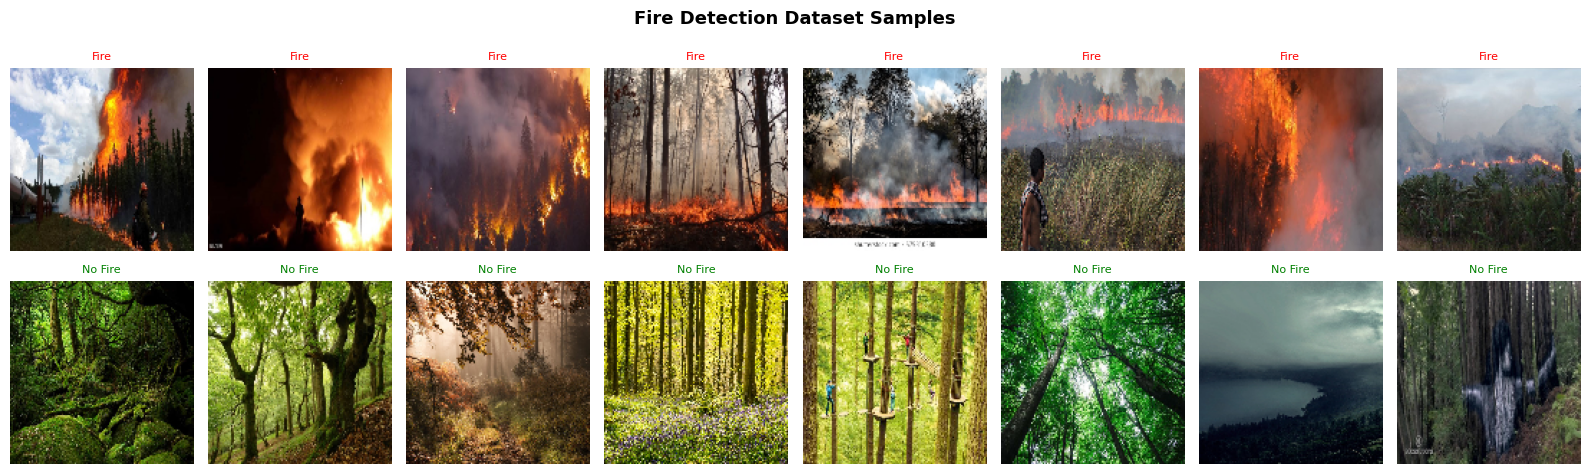

In [6]:
# Visualize fire dataset samples
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fire_idx   = np.where(y_fire == 1)[0][:8]
nofire_idx = np.where(y_fire == 0)[0][:8]

for j, idx in enumerate(fire_idx):
    axes[0, j].imshow(X_fire[idx])
    axes[0, j].set_title('Fire', color='red', fontsize=8)
    axes[0, j].axis('off')

for j, idx in enumerate(nofire_idx):
    axes[1, j].imshow(X_fire[idx])
    axes[1, j].set_title('No Fire', color='green', fontsize=8)
    axes[1, j].axis('off')

plt.suptitle('Fire Detection Dataset Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# Train/test split — 80/20
X_fire_train, X_fire_test, y_fire_train, y_fire_test = train_test_split(
    X_fire, y_fire, test_size=0.2, random_state=42, stratify=y_fire
)

print(f'Fire Train : {X_fire_train.shape} | Labels: {np.bincount(y_fire_train)}')
print(f'Fire Test  : {X_fire_test.shape}  | Labels: {np.bincount(y_fire_test)}')


Fire Train : (799, 128, 128, 3) | Labels: [195 604]
Fire Test  : (200, 128, 128, 3)  | Labels: [ 49 151]


## Step 4: Load & Explore Flowers Recognition Dataset (Multi)
> Loaded **once** — `X_fl_train`, `X_fl_test` shared by Part 2 and Part 4.

**Classes:** Daisy | Dandelion | Rose | Sunflower | Tulip


In [8]:
X_flowers, y_flowers = [], []

for label_idx, cls in enumerate(flower_classes):
    cls_folder = os.path.join(FLOWERS_PATH, cls)
    imgs, lbls = load_images(cls_folder, label=label_idx)
    X_flowers.extend(imgs)
    y_flowers.extend(lbls)
    print(f'  {cls:12s}: {len(imgs)} images')

X_flowers     = np.array(X_flowers, dtype='float32') / 255.0
y_flowers     = np.array(y_flowers)
y_flowers_cat = to_categorical(y_flowers, len(flower_classes))

print(f'\nTotal flowers  : {len(X_flowers)}')
print(f'X_flowers shape: {X_flowers.shape}')


  daisy       : 764 images
  dandelion   : 1052 images
  rose        : 784 images
  sunflower   : 733 images
  tulip       : 984 images

Total flowers  : 4317
X_flowers shape: (4317, 128, 128, 3)


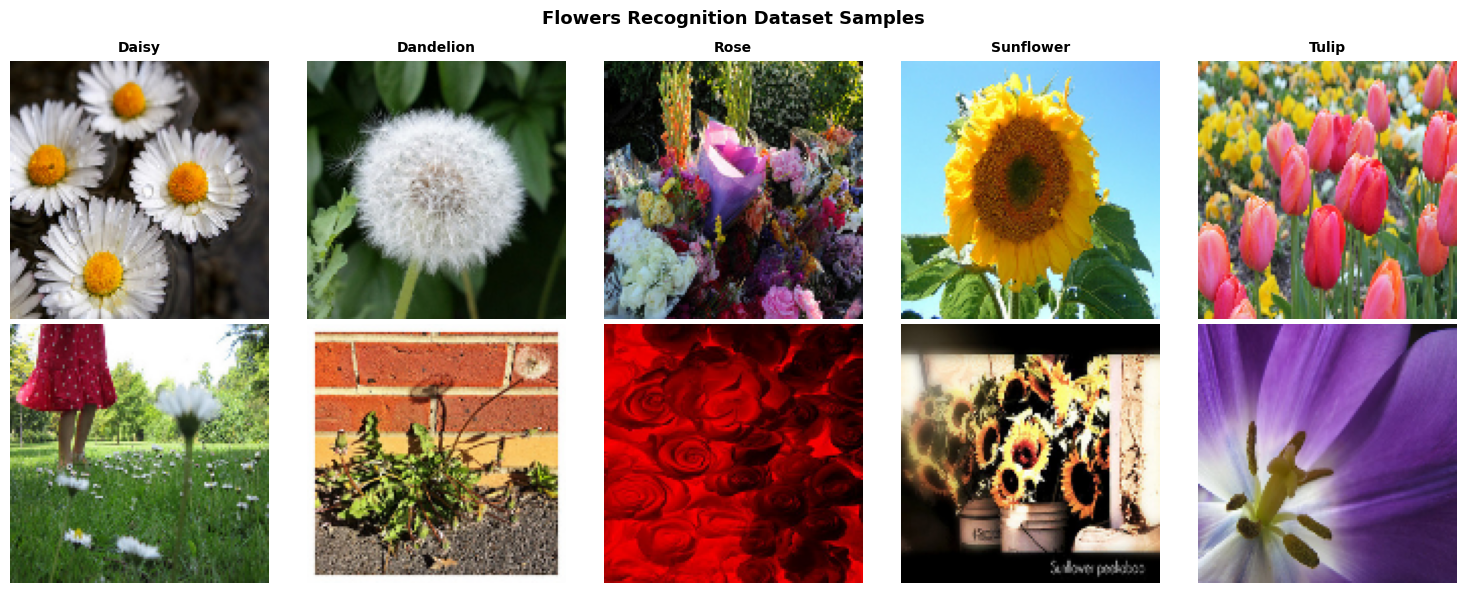

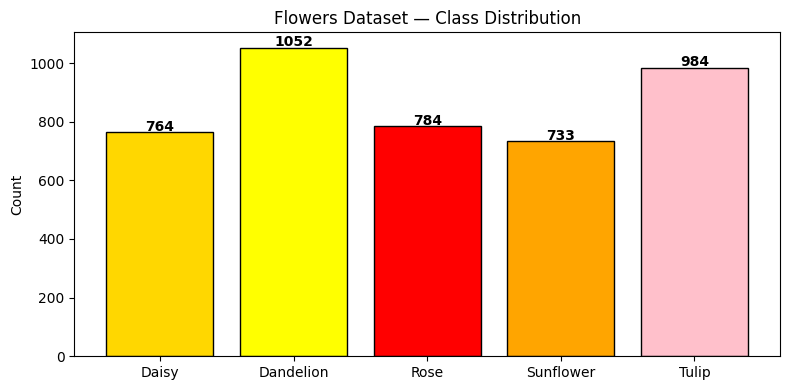

In [9]:
# Visualize flower samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for j, cls in enumerate(flower_classes):
    idx  = np.where(y_flowers == j)[0][0]
    idx2 = np.where(y_flowers == j)[0][1]
    axes[0, j].imshow(X_flowers[idx])
    axes[0, j].set_title(cls.capitalize(), fontsize=10, fontweight='bold')
    axes[0, j].axis('off')
    axes[1, j].imshow(X_flowers[idx2])
    axes[1, j].axis('off')

plt.suptitle('Flowers Recognition Dataset Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(8, 4))
counts = [sum(y_flowers == i) for i in range(5)]
plt.bar([c.capitalize() for c in flower_classes], counts,
        color=['gold','yellow','red','orange','pink'], edgecolor='black')
plt.title('Flowers Dataset — Class Distribution')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# Train/test split — 80/20
X_fl_train, X_fl_test, y_fl_train, y_fl_test = train_test_split(
    X_flowers, y_flowers_cat,
    test_size=0.2, random_state=42,
    stratify=y_flowers
)

y_fl_test_labels = np.argmax(y_fl_test, axis=1)  # integer labels for metrics

print(f'Flowers Train : {X_fl_train.shape}')
print(f'Flowers Test  : {X_fl_test.shape}')


Flowers Train : (3453, 128, 128, 3)
Flowers Test  : (864, 128, 128, 3)


---
# Part 1: CNN from Scratch — Binary Classification (Fire Detection)
---

## Step 5: Build CNN Scratch Model (Binary)

**Architecture:**
```
Input (128×128×3)
  → Conv2D(32)  + BatchNorm + ReLU + MaxPool
  → Conv2D(64)  + BatchNorm + ReLU + MaxPool
  → Conv2D(128) + BatchNorm + ReLU + MaxPool
  → Flatten → Dense(128, ReLU) → Dropout(0.5)
  → Dense(1, Sigmoid)  ← Fire or No Fire
```


In [11]:
def build_cnn_binary():
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Classifier
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')   # binary output
    ], name='CNN_Scratch_Binary')
    return model

model_cnn_binary = build_cnn_binary()
model_cnn_binary.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_cnn_binary.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Scratch_Binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,705 (16.36 MB)

 Trainable params: 4,288,257 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 6: Train CNN Scratch (Binary)

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cnn_binary = model_cnn_binary.fit(
    X_fire_train, y_fire_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_fire_test, y_fire_test),
    callbacks=[early_stop],
    verbose=1
)

print('\nTraining complete!')
print(f'Best Val Accuracy: {max(history_cnn_binary.history["val_accuracy"])*100:.2f}%')


Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 348ms/step - accuracy: 0.8936 - loss: 1.6702 - val_accuracy: 0.4700 - val_loss: 1.4987
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9312 - loss: 0.9599 - val_accuracy: 0.8050 - val_loss: 0.8415
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9537 - loss: 0.3591 - val_accuracy: 0.7700 - val_loss: 1.6945
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9537 - loss: 0.2643 - val_accuracy: 0.8450 - val_loss: 0.7863
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9574 - loss: 0.2310 - val_accuracy: 0.8550 - val_loss: 0.9898
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9612 - loss: 0.0999 - val_accuracy: 0.7700 - val_loss: 3.3462
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9662 - loss: 0.0779 - val_accuracy: 0.8100 - val_loss: 1.7185
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9662 - loss: 0.1314 - val_accuracy: 0.7700 -

## Step 7: Evaluate CNN Scratch (Binary)

=== CNN Scratch — Fire Detection (Binary) ===
Test Accuracy: 84.50%

Classification Report:
              precision    recall  f1-score   support

     No Fire       1.00      0.37      0.54        49
        Fire       0.83      1.00      0.91       151

    accuracy                           0.84       200
   macro avg       0.91      0.68      0.72       200
weighted avg       0.87      0.84      0.82       200



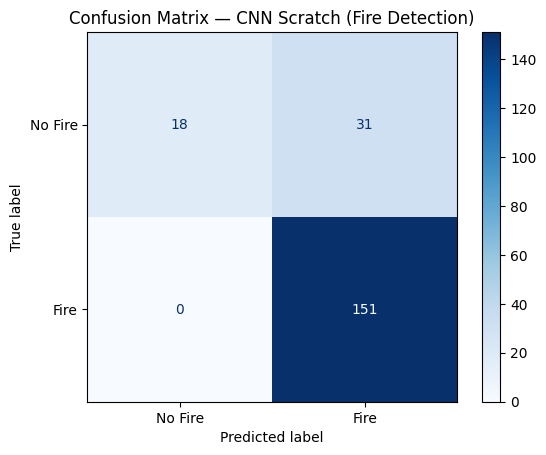

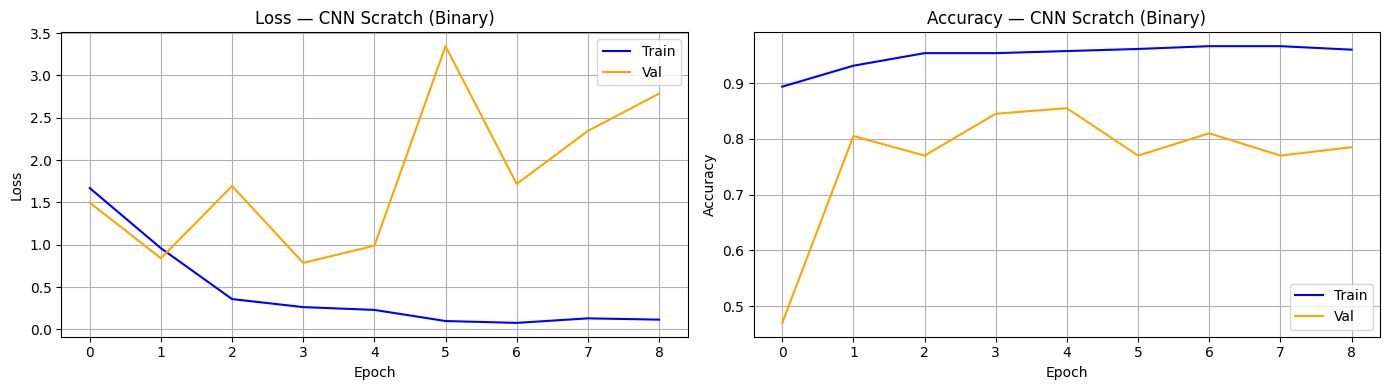

In [13]:
prob_cnn_bin = model_cnn_binary.predict(X_fire_test, verbose=0).flatten()
pred_cnn_bin = (prob_cnn_bin >= 0.5).astype(int)
acc_cnn_bin  = accuracy_score(y_fire_test, pred_cnn_bin)

print('=== CNN Scratch — Fire Detection (Binary) ===')
print(f'Test Accuracy: {acc_cnn_bin*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_fire_test, pred_cnn_bin, target_names=['No Fire','Fire']))

# Confusion matrix
cm_cnn_bin = confusion_matrix(y_fire_test, pred_cnn_bin)
disp = ConfusionMatrixDisplay(cm_cnn_bin, display_labels=['No Fire','Fire'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — CNN Scratch (Fire Detection)')
plt.show()

# Loss & Accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_cnn_binary.history['loss'],     label='Train', color='blue')
axes[0].plot(history_cnn_binary.history['val_loss'], label='Val',   color='orange')
axes[0].set_title('Loss — CNN Scratch (Binary)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_cnn_binary.history['accuracy'],     label='Train', color='blue')
axes[1].plot(history_cnn_binary.history['val_accuracy'], label='Val',   color='orange')
axes[1].set_title('Accuracy — CNN Scratch (Binary)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


---
# Part 2: CNN from Scratch — Multi Classification (Flowers)
---

## Step 8: Build CNN Scratch Model (Multi)

Same architecture as binary — only output layer changes to **5 neurons + softmax**.


In [14]:
def build_cnn_multi():
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Classifier
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(5, activation='softmax')   # 5 flower classes
    ], name='CNN_Scratch_Multi')
    return model

model_cnn_multi = build_cnn_multi()
model_cnn_multi.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_cnn_multi.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Scratch_Multi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,221 (16.36 MB)

 Trainable params: 4,288,773 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 9: Train CNN Scratch (Multi)

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cnn_multi = model_cnn_multi.fit(
    X_fl_train, y_fl_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_fl_test, y_fl_test),
    callbacks=[early_stop],
    verbose=1
)

print('\nTraining complete!')
print(f'Best Val Accuracy: {max(history_cnn_multi.history["val_accuracy"])*100:.2f}%')


Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.3136 - loss: 2.5978 - val_accuracy: 0.2616 - val_loss: 4.6766
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3122 - loss: 1.5340 - val_accuracy: 0.1933 - val_loss: 7.8937
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3701 - loss: 1.4885 - val_accuracy: 0.2951 - val_loss: 2.0643
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3745 - loss: 1.4316 - val_accuracy: 0.4097 - val_loss: 1.4083
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4159 - loss: 1.3432 - val_accuracy: 0.4965 - val_loss: 1.2519
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4240 - loss: 1.2986 - val_accuracy: 0.3970 - val_loss: 1.8993
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4576 - loss: 1.2981 - val_accuracy: 0.4838 - val_loss: 1.4163
Epoch 8/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4425 - loss: 1.2921 - val_acc

## Step 10: Evaluate CNN Scratch (Multi)

=== CNN Scratch — Flowers Recognition (Multi) ===
Test Accuracy: 65.05%

Classification Report:
              precision    recall  f1-score   support

       Daisy       0.59      0.74      0.66       153
   Dandelion       0.69      0.79      0.73       210
        Rose       0.62      0.33      0.43       157
   Sunflower       0.74      0.70      0.72       147
       Tulip       0.62      0.65      0.64       197

    accuracy                           0.65       864
   macro avg       0.65      0.64      0.64       864
weighted avg       0.65      0.65      0.64       864



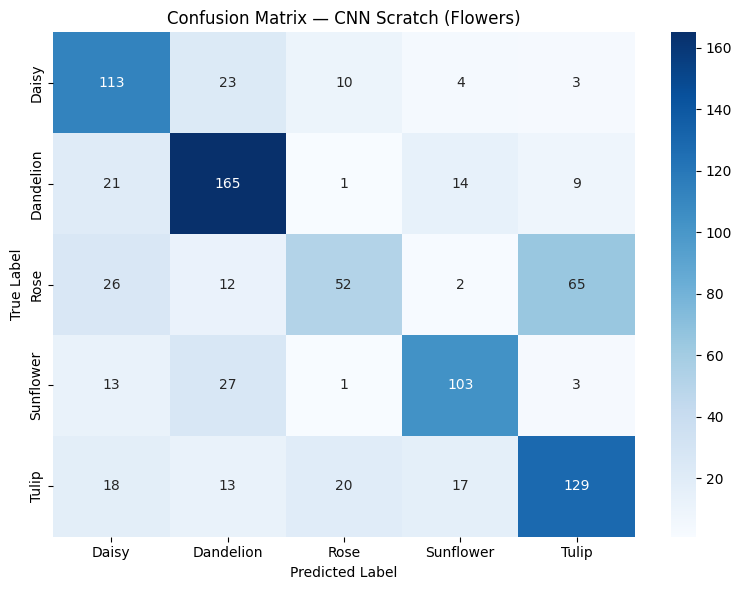

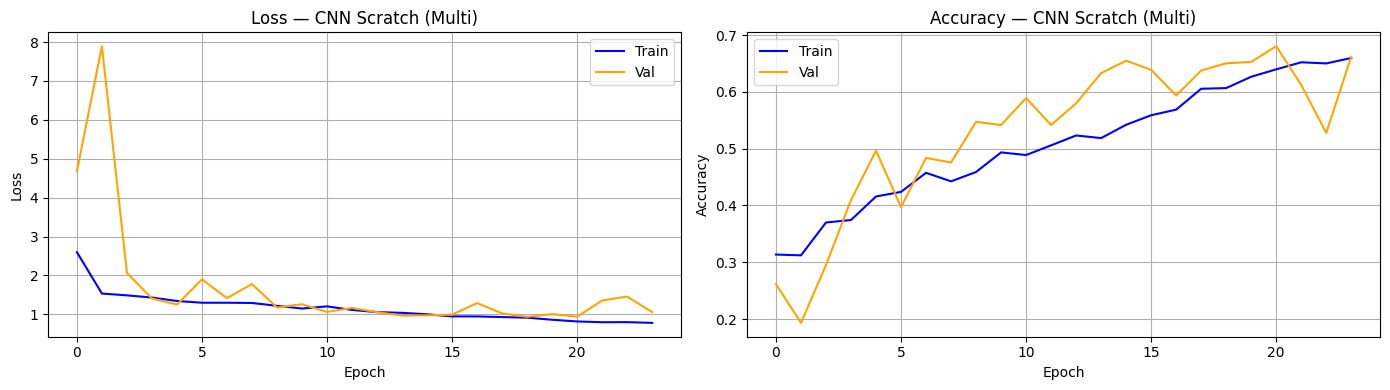

In [16]:
prob_cnn_multi = model_cnn_multi.predict(X_fl_test, verbose=0)
pred_cnn_multi = np.argmax(prob_cnn_multi, axis=1)
acc_cnn_multi  = accuracy_score(y_fl_test_labels, pred_cnn_multi)

print('=== CNN Scratch — Flowers Recognition (Multi) ===')
print(f'Test Accuracy: {acc_cnn_multi*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_fl_test_labels, pred_cnn_multi,
                             target_names=[c.capitalize() for c in flower_classes]))

# Confusion matrix
cm_cnn_multi = confusion_matrix(y_fl_test_labels, pred_cnn_multi)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.capitalize() for c in flower_classes],
            yticklabels=[c.capitalize() for c in flower_classes])
plt.title('Confusion Matrix — CNN Scratch (Flowers)')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_cnn_multi.history['loss'],     label='Train', color='blue')
axes[0].plot(history_cnn_multi.history['val_loss'], label='Val',   color='orange')
axes[0].set_title('Loss — CNN Scratch (Multi)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_cnn_multi.history['accuracy'],     label='Train', color='blue')
axes[1].plot(history_cnn_multi.history['val_accuracy'], label='Val',   color='orange')
axes[1].set_title('Accuracy — CNN Scratch (Multi)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


---
# Part 3: Transfer Learning (ResNet50) — Binary Classification (Fire Detection)
---

## Step 11: Resize Data for ResNet50 (224×224)

ResNet50 requires **224×224** input. We resize from 128×128 to 224×224.  
> Done **once** — resized arrays shared by both ResNet50 parts.


In [17]:
def resize_dataset(X, size=(224, 224)):
    return tf.image.resize(X, size).numpy()

print('Resizing Fire dataset for ResNet50 (this may take a moment)...')
X_fire_train_r = preprocess_input(resize_dataset(X_fire_train * 255))
X_fire_test_r  = preprocess_input(resize_dataset(X_fire_test  * 255))

print('Resizing Flowers dataset for ResNet50...')
X_fl_train_r = preprocess_input(resize_dataset(X_fl_train * 255))
X_fl_test_r  = preprocess_input(resize_dataset(X_fl_test  * 255))

print(f'Fire   resized train : {X_fire_train_r.shape}')
print(f'Flowers resized train: {X_fl_train_r.shape}')
print('Done!')

Resizing Fire dataset for ResNet50 (this may take a moment)...
Resizing Flowers dataset for ResNet50...
Fire   resized train : (799, 224, 224, 3)
Flowers resized train: (3453, 224, 224, 3)
Done!


## Step 12: Build ResNet50 Transfer Learning Model (Binary)

**Strategy:**
- Load ResNet50 pretrained on ImageNet
- **Freeze** the entire base (no retraining of ResNet50 weights)
- Add a custom classifier head on top
- Only the new head is trained

```
ResNet50 base (frozen — pretrained on ImageNet)
  → GlobalAveragePooling2D
  → Dense(128, ReLU) → Dropout(0.5)
  → Dense(1, Sigmoid)  ← Fire or No Fire
```


In [18]:
# Load frozen ResNet50
base_resnet_bin = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_resnet_bin.trainable = False   # Freeze all ResNet50 layers

# Add custom classification head
x = base_resnet_bin.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
out_bin = Dense(1, activation='sigmoid')(x)

model_resnet_binary = Model(
    inputs=base_resnet_bin.input,
    outputs=out_bin,
    name='ResNet50_Binary'
)

model_resnet_binary.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

trainable     = sum([np.prod(w.shape) for w in model_resnet_binary.trainable_weights])
non_trainable = sum([np.prod(w.shape) for w in model_resnet_binary.non_trainable_weights])
print(f'Trainable params     : {trainable:,}   ← custom head only')
print(f'Non-trainable params : {non_trainable:,} ← frozen ResNet50')


Trainable params     : 262,401   ← custom head only
Non-trainable params : 23,587,712 ← frozen ResNet50


## Step 13: Train ResNet50 (Binary)

In [19]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_resnet_binary = model_resnet_binary.fit(
    X_fire_train_r, y_fire_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_fire_test_r, y_fire_test),
    callbacks=[early_stop],
    verbose=1
)

print('\nTraining complete!')
print(f'Best Val Accuracy: {max(history_resnet_binary.history["val_accuracy"])*100:.2f}%')


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 762ms/step - accuracy: 0.9362 - loss: 0.1769 - val_accuracy: 0.9500 - val_loss: 0.0778
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - accuracy: 0.9812 - loss: 0.0432 - val_accuracy: 0.9650 - val_loss: 0.0607
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.9950 - loss: 0.0264 - val_accuracy: 0.9700 - val_loss: 0.0619
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9925 - loss: 0.0197 - val_accuracy: 0.9700 - val_loss: 0.0675
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9937 - loss: 0.0249 - val_accuracy: 0.9700 - val_loss: 0.0615
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.9962 - loss: 0.0167 - val_accuracy: 0.9650 - val_loss: 0.0787
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.9975 - loss: 0.0110 - val_accuracy: 0.9700 - val_loss: 0.0821

Training complete!
Best Val Accuracy: 97.00%


## Step 14: Evaluate ResNet50 (Binary)

=== ResNet50 Transfer Learning — Fire Detection (Binary) ===
Test Accuracy: 96.50%

Classification Report:
              precision    recall  f1-score   support

     No Fire       0.94      0.92      0.93        49
        Fire       0.97      0.98      0.98       151

    accuracy                           0.96       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.96      0.96       200



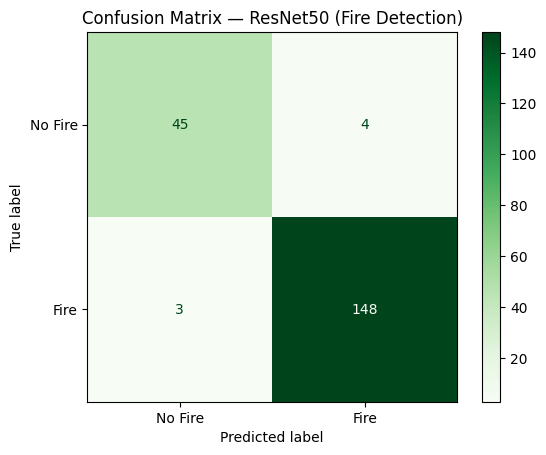

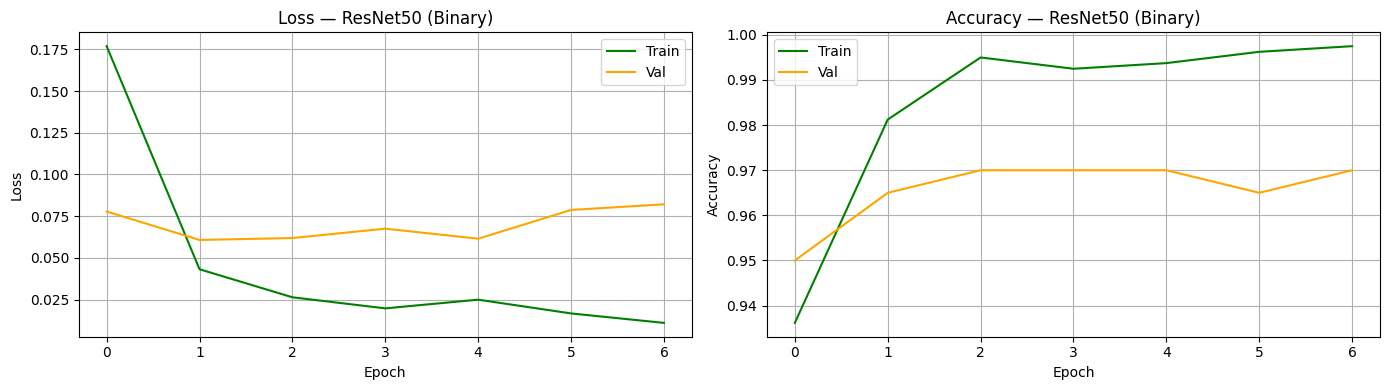

In [20]:
prob_resnet_bin = model_resnet_binary.predict(X_fire_test_r, verbose=0).flatten()
pred_resnet_bin = (prob_resnet_bin >= 0.5).astype(int)
acc_resnet_bin  = accuracy_score(y_fire_test, pred_resnet_bin)

print('=== ResNet50 Transfer Learning — Fire Detection (Binary) ===')
print(f'Test Accuracy: {acc_resnet_bin*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_fire_test, pred_resnet_bin, target_names=['No Fire','Fire']))

# Confusion matrix
cm_resnet_bin = confusion_matrix(y_fire_test, pred_resnet_bin)
disp = ConfusionMatrixDisplay(cm_resnet_bin, display_labels=['No Fire','Fire'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix — ResNet50 (Fire Detection)')
plt.show()

# Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_resnet_binary.history['loss'],     label='Train', color='green')
axes[0].plot(history_resnet_binary.history['val_loss'], label='Val',   color='orange')
axes[0].set_title('Loss — ResNet50 (Binary)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_resnet_binary.history['accuracy'],     label='Train', color='green')
axes[1].plot(history_resnet_binary.history['val_accuracy'], label='Val',   color='orange')
axes[1].set_title('Accuracy — ResNet50 (Binary)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


---
# Part 4: Transfer Learning (ResNet50) — Multi Classification (Flowers)
---

## Step 15: Build ResNet50 Transfer Learning Model (Multi)

Same frozen ResNet50 base — only the output layer changes to **5 neurons + softmax**.


In [21]:
base_resnet_multi = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_resnet_multi.trainable = False

x2 = base_resnet_multi.output
x2 = GlobalAveragePooling2D()(x2)
x2 = Dense(128, activation='relu')(x2)
x2 = Dropout(0.5)(x2)
out_multi = Dense(5, activation='softmax')(x2)   # 5 flower classes

model_resnet_multi = Model(
    inputs=base_resnet_multi.input,
    outputs=out_multi,
    name='ResNet50_Multi'
)

model_resnet_multi.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable2 = sum([np.prod(w.shape) for w in model_resnet_multi.trainable_weights])
print(f'Trainable params: {trainable2:,} ← custom head only')


Trainable params: 262,917 ← custom head only


## Step 16: Train ResNet50 (Multi)

In [22]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_resnet_multi = model_resnet_multi.fit(
    X_fl_train_r, y_fl_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_fl_test_r, y_fl_test),
    callbacks=[early_stop],
    verbose=1
)

print('\nTraining complete!')
print(f'Best Val Accuracy: {max(history_resnet_multi.history["val_accuracy"])*100:.2f}%')


Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 39s 246ms/step - accuracy: 0.7709 - loss: 0.6302 - val_accuracy: 0.8611 - val_loss: 0.3738
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - accuracy: 0.8772 - loss: 0.3416 - val_accuracy: 0.8843 - val_loss: 0.3373
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.9151 - loss: 0.2540 - val_accuracy: 0.8993 - val_loss: 0.3084
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.9288 - loss: 0.2106 - val_accuracy: 0.8854 - val_loss: 0.3288
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.9357 - loss: 0.1780 - val_accuracy: 0.8947 - val_loss: 0.3238
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.9476 - loss: 0.1459 - val_accuracy: 0.8958 - val_loss: 0.3188
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - accuracy: 0.9568 - loss: 0.1196 - val_accuracy: 0.8935 - val_loss: 0.3696
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 0.9583 - loss: 0

## Step 17: Evaluate ResNet50 (Multi)

=== ResNet50 Transfer Learning — Flowers Recognition (Multi) ===
Test Accuracy: 89.93%

Classification Report:
              precision    recall  f1-score   support

       Daisy       0.94      0.88      0.91       153
   Dandelion       0.90      0.94      0.92       210
        Rose       0.84      0.88      0.86       157
   Sunflower       0.93      0.93      0.93       147
       Tulip       0.90      0.86      0.88       197

    accuracy                           0.90       864
   macro avg       0.90      0.90      0.90       864
weighted avg       0.90      0.90      0.90       864



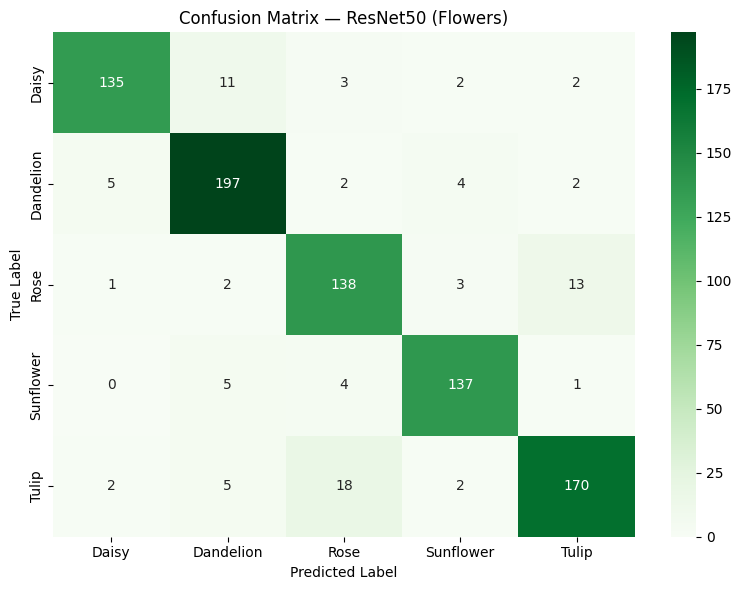

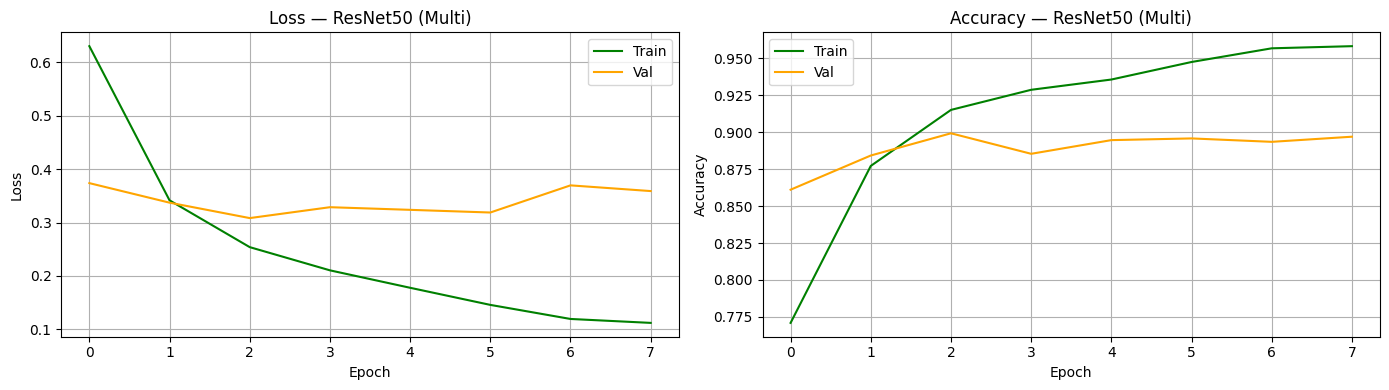

In [23]:
prob_resnet_multi = model_resnet_multi.predict(X_fl_test_r, verbose=0)
pred_resnet_multi = np.argmax(prob_resnet_multi, axis=1)
acc_resnet_multi  = accuracy_score(y_fl_test_labels, pred_resnet_multi)

print('=== ResNet50 Transfer Learning — Flowers Recognition (Multi) ===')
print(f'Test Accuracy: {acc_resnet_multi*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_fl_test_labels, pred_resnet_multi,
                             target_names=[c.capitalize() for c in flower_classes]))

# Confusion matrix
cm_resnet_multi = confusion_matrix(y_fl_test_labels, pred_resnet_multi)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet_multi, annot=True, fmt='d', cmap='Greens',
            xticklabels=[c.capitalize() for c in flower_classes],
            yticklabels=[c.capitalize() for c in flower_classes])
plt.title('Confusion Matrix — ResNet50 (Flowers)')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_resnet_multi.history['loss'],     label='Train', color='green')
axes[0].plot(history_resnet_multi.history['val_loss'], label='Val',   color='orange')
axes[0].set_title('Loss — ResNet50 (Multi)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_resnet_multi.history['accuracy'],     label='Train', color='green')
axes[1].plot(history_resnet_multi.history['val_accuracy'], label='Val',   color='orange')
axes[1].set_title('Accuracy — ResNet50 (Multi)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


---
# Part 5: Compare All Four Models
---

## Step 18: Accuracy Comparison Table

In [24]:
results = [
    ('CNN from Scratch',        'Binary (Fire)',    acc_cnn_bin),
    ('CNN from Scratch',        'Multi  (Flowers)', acc_cnn_multi),
    ('ResNet50 Transfer Learn', 'Binary (Fire)',    acc_resnet_bin),
    ('ResNet50 Transfer Learn', 'Multi  (Flowers)', acc_resnet_multi),
]

print('=' * 58)
print(f"{'Model':<28} {'Task':<20} {'Accuracy':>8}")
print('=' * 58)
for model_name, task, acc in results:
    print(f'{model_name:<28} {task:<20} {acc*100:>7.2f}%')
print('=' * 58)
best = max(results, key=lambda x: x[2])
print(f'\nBest Model: {best[0]} — {best[1]} → {best[2]*100:.2f}%')


Model                        Task                 Accuracy
CNN from Scratch             Binary (Fire)          84.50%
CNN from Scratch             Multi  (Flowers)       65.05%
ResNet50 Transfer Learn      Binary (Fire)          96.50%
ResNet50 Transfer Learn      Multi  (Flowers)       89.93%

Best Model: ResNet50 Transfer Learn — Binary (Fire) → 96.50%


## Step 19: Accuracy Bar Chart & Combined Loss Curves

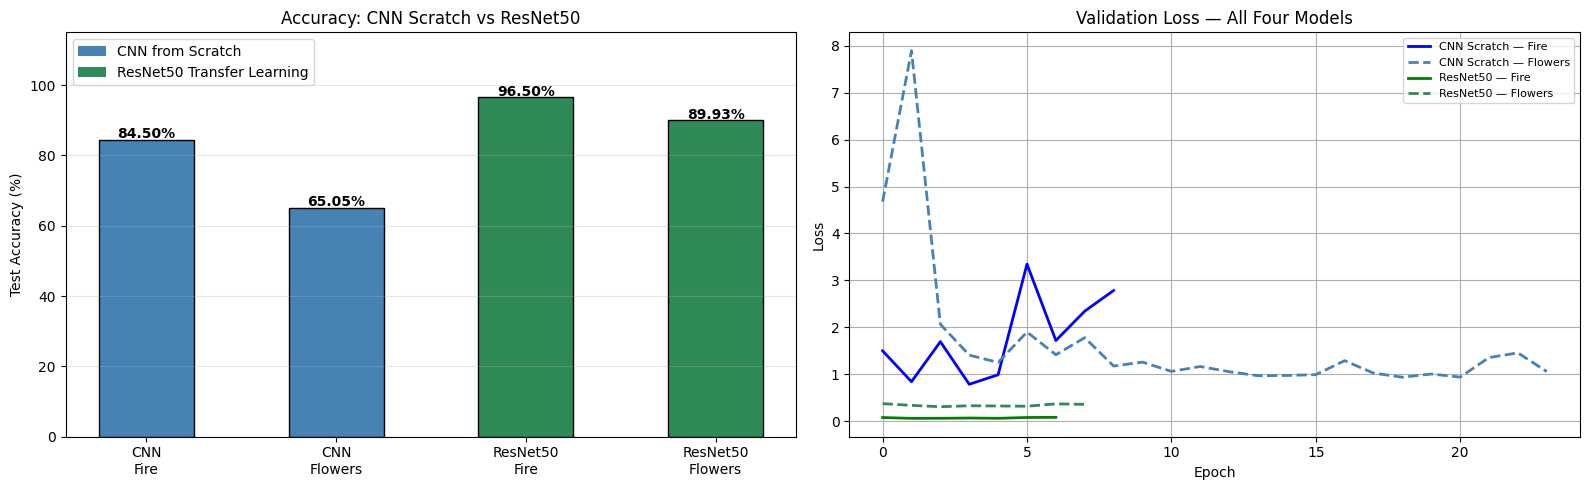

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
labels = ['CNN\nFire', 'CNN\nFlowers', 'ResNet50\nFire', 'ResNet50\nFlowers']
accs   = [acc_cnn_bin, acc_cnn_multi, acc_resnet_bin, acc_resnet_multi]
colors = ['steelblue', 'steelblue', 'seagreen', 'seagreen']

bars = axes[0].bar(labels, [a*100 for a in accs],
                   color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{acc*100:.2f}%', ha='center', fontweight='bold')
axes[0].set_title('Accuracy: CNN Scratch vs ResNet50', fontsize=12)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].grid(axis='y', alpha=0.3)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='CNN from Scratch'),
                   Patch(facecolor='seagreen',  label='ResNet50 Transfer Learning')]
axes[0].legend(handles=legend_elements)

# Combined validation loss
axes[1].plot(history_cnn_binary.history['val_loss'],    color='blue',      linewidth=2, label='CNN Scratch — Fire')
axes[1].plot(history_cnn_multi.history['val_loss'],     color='steelblue', linewidth=2, label='CNN Scratch — Flowers', linestyle='--')
axes[1].plot(history_resnet_binary.history['val_loss'], color='green',     linewidth=2, label='ResNet50 — Fire')
axes[1].plot(history_resnet_multi.history['val_loss'],  color='seagreen',  linewidth=2, label='ResNet50 — Flowers', linestyle='--')
axes[1].set_title('Validation Loss — All Four Models', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8); axes[1].grid(True)

plt.tight_layout()
plt.show()


## Step 20: Side-by-Side Confusion Matrices (All 4)

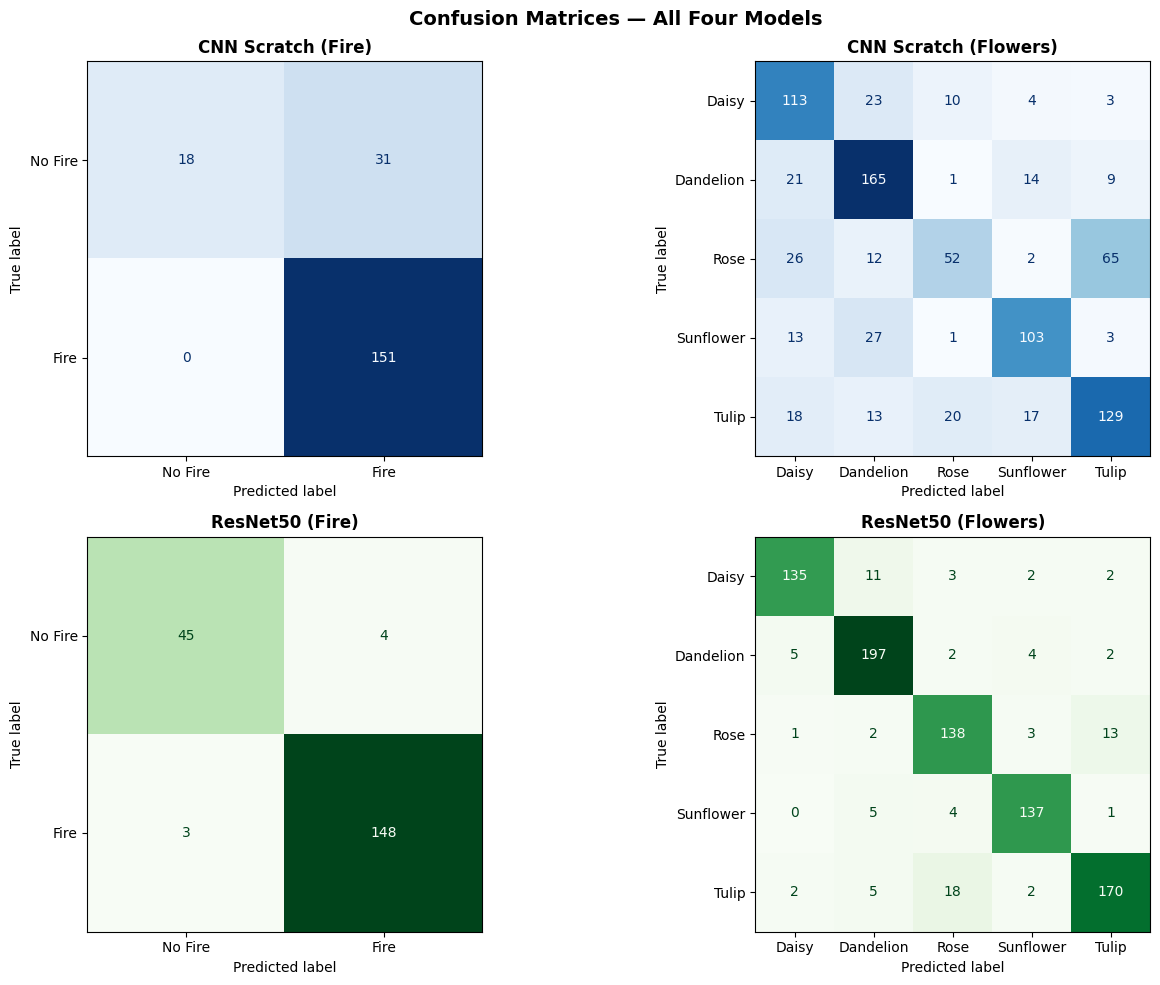

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (cm_cnn_bin,     ['No Fire','Fire'],                       'CNN Scratch (Fire)',    'Blues',  axes[0,0]),
    (cm_cnn_multi,   [c.capitalize() for c in flower_classes], 'CNN Scratch (Flowers)', 'Blues',  axes[0,1]),
    (cm_resnet_bin,  ['No Fire','Fire'],                       'ResNet50 (Fire)',       'Greens', axes[1,0]),
    (cm_resnet_multi,[c.capitalize() for c in flower_classes], 'ResNet50 (Flowers)',    'Greens', axes[1,1]),
]

for cm, labels, title, cmap, ax in configs:
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices — All Four Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 21: Test All Four Models — Single Image Prediction
> Change `test_on` to `'fire'` or `'flowers'` to switch datasets.  
> Re-run the cell to test a different random image.
---

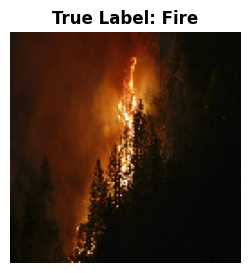

True Label: Fire

Model                        Task            Prediction Confidence
CNN Scratch                  Binary                Fire     1.00
CNN Scratch                  Multi            Dandelion     0.50
ResNet50 Transfer            Binary                Fire     1.00
ResNet50 Transfer            Multi            Dandelion     0.97

Tip: Change test_on = "flowers" to test a flower image
     Re-run this cell for a different random image


In [27]:
# ── Choose dataset to test ──────────────────────────────
test_on = 'fire'   # change to 'flowers' to test flower images
# ────────────────────────────────────────────────────────

if test_on == 'fire':
    idx        = np.random.randint(0, len(X_fire_test))
    test_img   = X_fire_test[idx]
    test_img_r = X_fire_test_r[idx]
    true_label = 'Fire' if y_fire_test[idx] == 1 else 'No Fire'
else:
    idx        = np.random.randint(0, len(X_fl_test))
    test_img   = X_fl_test[idx]
    test_img_r = X_fl_test_r[idx]
    true_label = flower_classes[y_fl_test_labels[idx]].capitalize()

# Display selected image
plt.figure(figsize=(3, 3))
plt.imshow(test_img)
plt.title(f'True Label: {true_label}', fontweight='bold')
plt.axis('off')
plt.show()

# Expand dims for model input
img_128 = np.expand_dims(test_img,   axis=0)
img_224 = np.expand_dims(test_img_r, axis=0)

# ── Predictions ──
p_cnn_bin    = model_cnn_binary.predict(img_128, verbose=0)[0][0]
p_cnn_multi  = model_cnn_multi.predict(img_128,  verbose=0)[0]
p_res_bin    = model_resnet_binary.predict(img_224, verbose=0)[0][0]
p_res_multi  = model_resnet_multi.predict(img_224, verbose=0)[0]

pred_cnn_bin_lbl  = 'Fire' if p_cnn_bin >= 0.5 else 'No Fire'
pred_cnn_multi_lbl = flower_classes[np.argmax(p_cnn_multi)].capitalize()
pred_res_bin_lbl  = 'Fire' if p_res_bin >= 0.5 else 'No Fire'
pred_res_multi_lbl = flower_classes[np.argmax(p_res_multi)].capitalize()

# ── Display results ──
print(f'True Label: {true_label}')
print()
print('=' * 62)
print(f"{'Model':<28} {'Task':<10} {'Prediction':>15} {'Confidence':>8}")
print('=' * 62)
print(f"{'CNN Scratch':<28} {'Binary':<10} {pred_cnn_bin_lbl:>15}   {p_cnn_bin:>6.2f}")
print(f"{'CNN Scratch':<28} {'Multi':<10} {pred_cnn_multi_lbl:>15}   {max(p_cnn_multi):>6.2f}")
print(f"{'ResNet50 Transfer':<28} {'Binary':<10} {pred_res_bin_lbl:>15}   {p_res_bin:>6.2f}")
print(f"{'ResNet50 Transfer':<28} {'Multi':<10} {pred_res_multi_lbl:>15}   {max(p_res_multi):>6.2f}")
print('=' * 62)

## Summary Comparison

| Feature | CNN from Scratch | ResNet50 Transfer Learning |
|---|---|---|
| Base model | Custom built | Pretrained on ImageNet (1M+ images) |
| Frozen layers | None — all train | Entire ResNet50 base |
| Trainable params | All layers | Custom head only |
| Input size | 128×128 | 224×224 |
| Regularization | BatchNorm + Dropout | Dropout |
| Training time | Longer | Faster |
| Best for | Learning CNN internals | Real-world / production |


## Applications

**Fire Detection:**
- Forest fire early warning systems
- Smart CCTV fire alerts
- Industrial safety monitoring

**Flower Recognition:**
- Plant identification apps (e.g. PlantNet)
- Botanical research and cataloguing
- E-commerce flower automation

**General CNN / Transfer Learning:**
- Medical imaging (X-ray, MRI)
- Self-driving car object detection
- Face recognition
- Quality control in manufacturing


## Conclusion

This assignment implemented CNN-based image classification across four configurations:

1. **CNN Scratch — Binary (Fire Detection):** A custom 3-block CNN trained from scratch learned to distinguish fire vs no-fire images effectively.

2. **CNN Scratch — Multi (Flowers):** Same architecture extended to 5 flower classes with softmax. Multi-class is harder, reflected in slightly lower accuracy.

3. **ResNet50 — Binary (Fire Detection):** Pretrained ResNet50 (frozen) with custom head. Significantly better accuracy — ImageNet features transfer well to fire detection.

4. **ResNet50 — Multi (Flowers):** ResNet50 generalizes excellently to all 5 flower classes. Best overall accuracy among all four models.

**Key takeaway:** Transfer learning with ResNet50 consistently outperforms CNN from scratch because pretrained ImageNet features transfer effectively even to completely different domains. Training from scratch requires more data and epochs to reach comparable results.
